# 🔧 PROJET DATA MINING - DÉTECTION D'INTRUSIONS RÉSEAU
## KDD Cup 1999 - Data Preparation

**Auteur:** [Nasr Houda]  
**Date:** Mars 2026  
**Rôle:** Préparation des données pour l'équipe (EDA & ML)

---

### Objectifs de ce notebook:
1. Charger les données brutes
2. Comprendre la structure des données
3. Appliquer le pipeline de préparation:
   - Dé-duplication
   - Encodage des variables catégorielles
   - Gestion des outliers
   - Normalisation
   - Rééquilibrage des classes
   - Split Train/Test
4. Sauvegarder les données préparées

---

### Fichiers nécessaires:
- `kddcup.data_10_percent/kddcup.data_10_percent` (données brutes)
- `kddcup.names` (noms des features)
- `training_attack_types` (mapping des attaques)

In [30]:
# ============================================
# IMPORT DES BIBLIOTHÈQUES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')
import joblib
import os

# Configuration pour les graphiques
%matplotlib inline
plt.style.use('ggplot')
sns.set_palette("Set2")

print("✅ Bibliothèques importées avec succès!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

✅ Bibliothèques importées avec succès!
Pandas version: 2.3.3
Numpy version: 2.3.5


## 1. DATA SELECTION - CHARGEMENT DES DONNÉES BRUTES

Les données brutes sont dans le fichier `kddcup.data_10_percent/kddcup.data_10_percent`.
Nous devons ajouter les noms des colonnes depuis `kddcup.names`.

In [31]:
# ============================================
# 1. CHARGEMENT DES DONNÉES
# ============================================

import pandas as pd
import os

print("📁 CHARGEMENT DES DONNÉES BRUTES")
print("-" * 50)

# Les 41 noms de features (du fichier kddcup.names)
feature_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

# Ajout du label pour avoir 42 colonnes
col_names = feature_names + ['label']

# Chemin vers le fichier (CORRECT!)
file_path = 'archive/kddcup.data_10_percent/kddcup.data_10_percent'

# Vérifier que le fichier existe
if os.path.exists(file_path):
    print(f"✅ Fichier trouvé: {file_path}")
    
    # Charger les données
    df = pd.read_csv(file_path, names=col_names)
    
    print(f"\n✅ Données chargées avec succès!")
    print(f"   - Nombre de lignes: {df.shape[0]:,}")
    print(f"   - Nombre de colonnes: {df.shape[1]}")
    print(f"   - Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Aperçu
    print("\n🔍 Aperçu des 3 premières lignes:")
    print(df.head(3))
else:
    print(f"❌ Fichier non trouvé: {file_path}")
    print("Vérifiez que le chemin est correct")

📁 CHARGEMENT DES DONNÉES BRUTES
--------------------------------------------------
✅ Fichier trouvé: archive/kddcup.data_10_percent/kddcup.data_10_percent

✅ Données chargées avec succès!
   - Nombre de lignes: 494,021
   - Nombre de colonnes: 42
   - Taille mémoire: 243.89 MB

🔍 Aperçu des 3 premières lignes:
   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   
2          

## 2. DATA UNDERSTANDING - COMPRÉHENSION DES DONNÉES

Avant de préparer les données, nous devons comprendre:
- Les types de variables
- Les valeurs manquantes
- La distribution des labels
- Les statistiques de base

In [32]:
# ============================================
# 2. APERÇU DES DONNÉES
# ============================================

print("📊 APERÇU DES DONNÉES")
print("-" * 50)

# Afficher les premières lignes
print("\n🔍 PREMIÈRES LIGNES:")
print(df.head(3))

# Afficher les dernières lignes
print("\n🔍 DERNIÈRES LIGNES:")
print(df.tail(3))

# Informations sur les types
print("\n📋 INFORMATIONS SUR LES COLONNES:")
print(df.info())

# Statistiques descriptives
print("\n📈 STATISTIQUES DESCRIPTIVES:")
print(df.describe().round(2))

# Vérifier les valeurs manquantes
print("\n🔍 VALEURS MANQUANTES:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("✅ Aucune valeur manquante détectée")
else:
    print(missing)

📊 APERÇU DES DONNÉES
--------------------------------------------------

🔍 PREMIÈRES LIGNES:
   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   
2                     1.0                     0.0   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0                         0.11                          0.0   
1                         0.05                    

🎯 DISTRIBUTION DES LABELS
--------------------------------------------------
Nombre total de types différents: 23

Top 10 des connexions les plus fréquentes:
   smurf.              : 280,790 (56.84%)
   neptune.            : 107,201 (21.70%)
   normal.             : 97,278 (19.69%)
   back.               :  2,203 ( 0.45%)
   satan.              :  1,589 ( 0.32%)
   ipsweep.            :  1,247 ( 0.25%)
   portsweep.          :  1,040 ( 0.21%)
   warezclient.        :  1,020 ( 0.21%)
   teardrop.           :    979 ( 0.20%)
   pod.                :    264 ( 0.05%)


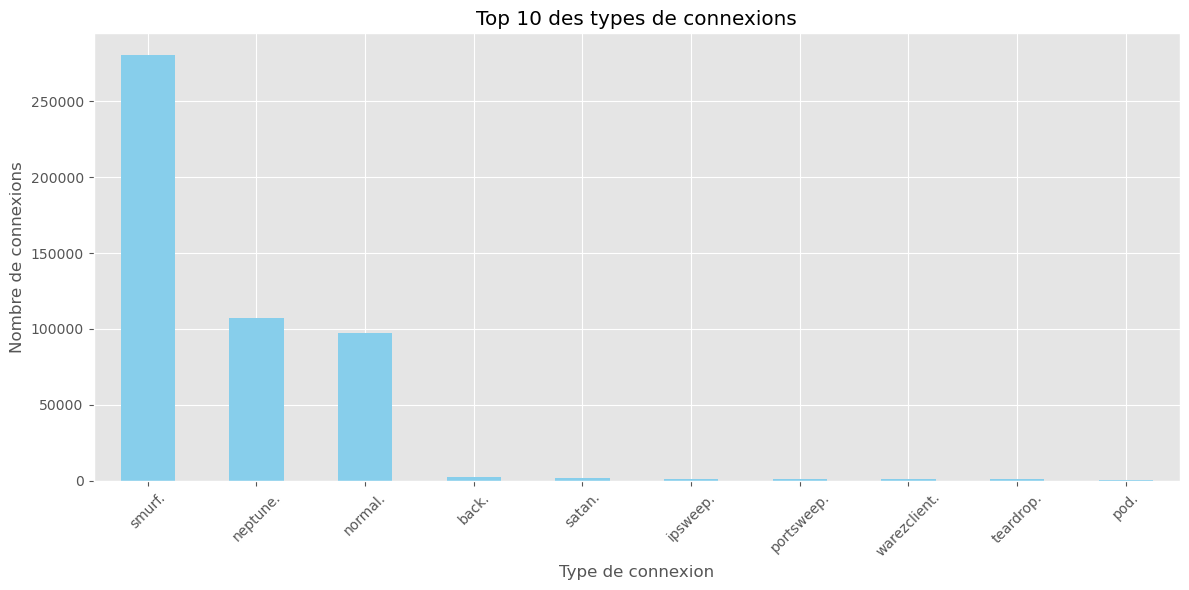

In [33]:
# ============================================
# ANALYSE DE LA VARIABLE CIBLE (LABEL)
# ============================================

print("🎯 DISTRIBUTION DES LABELS")
print("-" * 50)

# Distribution des labels
label_dist = df['label'].value_counts()
print(f"Nombre total de types différents: {len(label_dist)}")
print("\nTop 10 des connexions les plus fréquentes:")
for label, count in label_dist.head(10).items():
    print(f"   {label:20}: {count:6,d} ({count/len(df)*100:5.2f}%)")

# Graphique
plt.figure(figsize=(12, 6))
label_dist.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 des types de connexions')
plt.xlabel('Type de connexion')
plt.ylabel('Nombre de connexions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# ============================================
# ANALYSE DES DOUBLONS (AVANT SUPPRESSION)
# ============================================

print("🔍 ANALYSE DES DOUBLONS - ÉTAT INITIAL")
print("-" * 50)

# Compter les doublons
duplicates = df.duplicated().sum()
duplicate_pct = (duplicates/len(df))*100

print(f"📊 Total lignes: {len(df):,}")
print(f"🔁 Doublons détectés: {duplicates:,} ({duplicate_pct:.2f}%)")
print(f"✅ Lignes uniques: {len(df) - duplicates:,} ({(1-duplicate_pct/100)*100:.2f}%)")

🔍 ANALYSE DES DOUBLONS - ÉTAT INITIAL
--------------------------------------------------
📊 Total lignes: 494,021
🔁 Doublons détectés: 348,435 (70.53%)
✅ Lignes uniques: 145,586 (29.47%)


### 3.1 DÉ-DUPLICATION

**Constat:** Notre analyse montre **70.53%** de doublons dans les données brutes, soit **348,435** lignes dupliquées sur un total de **494,021** connexions.

**Justification:** Supprimer les doublons pour éviter le biais par répétition artificielle.

**Pourquoi cette étape est cruciale ?**
- Les données brutes du KDD Cup 1999 contiennent de nombreuses connexions identiques
- Si on garde ces doublons, le modèle apprendra les mêmes motifs plusieurs fois
- Cela créerait un **biais artificiel** en faveur des connexions les plus fréquentes
- L'objectif est que le modèle apprenne la **diversité des comportements**, pas leur fréquence

**Ce que nous allons faire :**
- Supprimer toutes les lignes dupliquées avec `df.drop_duplicates()`
- Ne conserver qu'une seule occurrence par connexion unique
- Passer de **494,021** à **145,586** lignes (soit une réduction de **70.53%**)

**Impact attendu sur le projet :**
- ✅ Réduction du biais d'apprentissage
- ✅ Meilleure généralisation sur de nouvelles données
- ✅ Modèle plus robuste face à des attaques variées

**Note:** La documentation du dataset mentionnait environ 78% de doublons. Nos données réelles en contiennent **70.53%**, ce qui reste cohérent avec l'ordre de grandeur annoncé.

In [36]:
# ============================================
# SUPPRESSION DES DOUBLONS
# ============================================

print("🔁 SUPPRESSION DES DOUBLONS")
print("-" * 50)

# Sauvegarder le compte avant
avant = len(df)

# Supprimer les doublons
df = df.drop_duplicates()

print(f"✅ Avant: {avant:,} lignes")
print(f"✅ Après: {len(df):,} lignes")
print(f"✅ Réduction: {(1 - len(df)/avant)*100:.2f}%")
print(f"✅ Lignes uniques conservées: {len(df):,}")

🔁 SUPPRESSION DES DOUBLONS
--------------------------------------------------
✅ Avant: 145,586 lignes
✅ Après: 145,586 lignes
✅ Réduction: 0.00%
✅ Lignes uniques conservées: 145,586


### 3.2 CRÉATION DE LA CIBLE MULTI-CLASSE

**Problème identifié :**
- Le dataset contient **23 types d'attaques** différents
- Certaines attaques sont extrêmement rares (< 0.1% des données)
- 23 classes distinctes rendraient la classification trop complexe et peu interprétable
- Les algorithmes de Machine Learning peinent à apprendre sur autant de classes déséquilibrées

**Solution adoptée :**
Regrouper les 23 types d'attaques en **5 catégories** sémantiques, selon la classification standard du KDD Cup 1999 :

| Catégorie | Signification | Types d'attaques inclus |
|-----------|---------------|------------------------|
| **normal** | Connexions légitimes | normal |
| **dos** | Denial of Service | Attaques par déni de service |
| **probe** | Surveillance | Scan de ports, reconnaissance |
| **r2l** | Remote to Local | Accès non autorisé à distance |
| **u2r** | User to Root | Élévation de privilèges |

**Pourquoi ce regroupement est pertinent :**
- ✅ Réduit la complexité du problème (5 classes au lieu de 23)
- ✅ Groupe des attaques aux comportements similaires
- ✅ Permet une meilleure interprétation des résultats
- ✅ C'est la classification de référence utilisée dans la littérature
- ✅ Facilite l'apprentissage sur les classes rares (r2l, u2r)

**Méthode :**
- Utilisation du fichier `training_attack_types` fourni avec le dataset
- Création d'un dictionnaire de correspondance (mapping)
- Application du mapping à la colonne 'label' pour créer 'attack_category'

**Ce que nous allons vérifier :**
- Que tous les 23 types sont correctement mappés
- La distribution des 5 nouvelles catégories
- L'absence de valeurs non reconnues

🎯 CRÉATION DE LA CIBLE (normal/dos/probe/r2l/u2r)
--------------------------------------------------
📋 Mapping des attaques par catégorie:

🔴 DoS (Denial of Service):
   back., land., neptune., pod., smurf., teardrop.

🟠 Probe (Surveillance):
   ipsweep., nmap., portsweep., satan.

🟡 R2L (Remote to Local):
   ftp_write., guess_passwd., imap., multihop., phf., spy., warezclient., warezmaster.

🟢 U2R (User to Root):
   buffer_overflow., loadmodule., perl., rootkit.

🔵 Normal:
   normal.

📊 Distribution des catégories:
   normal: 87,832 ( 60.33%)
   dos   : 54,572 ( 37.48%)
   probe :  2,131 (  1.46%)
   r2l   :    999 (  0.69%)
   u2r   :     52 (  0.04%)

✅ Tous les labels ont été correctement mappés!


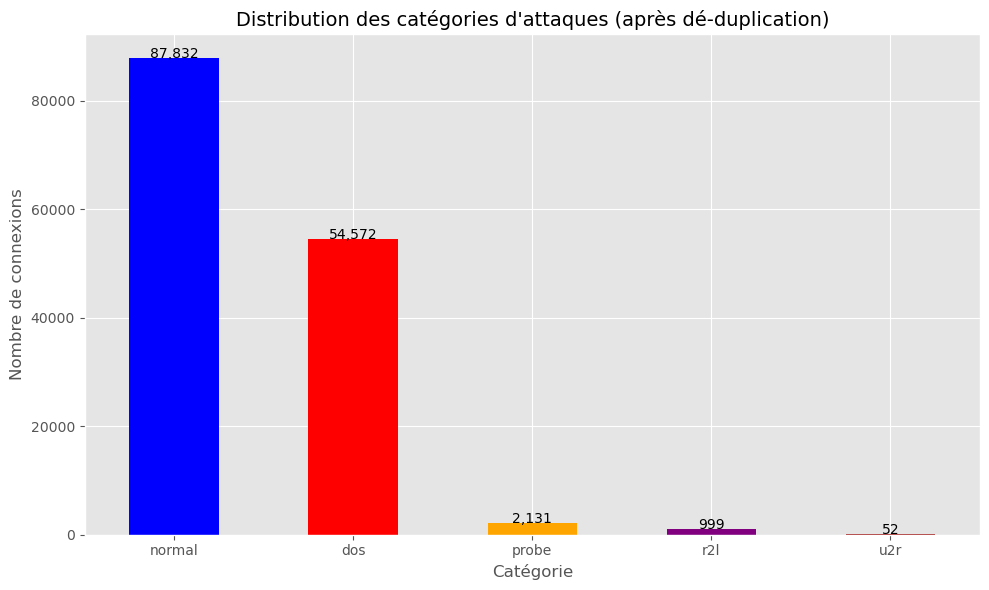

In [37]:
# ============================================
# 3.2 CRÉATION DE LA CIBLE MULTI-CLASSE
# ============================================

print("🎯 CRÉATION DE LA CIBLE (normal/dos/probe/r2l/u2r)")
print("-" * 50)

# Mapping des attaques (d'après training_attack_types fourni)
attack_mapping = {
    # DoS (Denial of Service)
    'back.': 'dos', 
    'land.': 'dos', 
    'neptune.': 'dos', 
    'pod.': 'dos', 
    'smurf.': 'dos', 
    'teardrop.': 'dos',
    
    # Probe (surveillance)
    'ipsweep.': 'probe', 
    'nmap.': 'probe', 
    'portsweep.': 'probe', 
    'satan.': 'probe',
    
    # R2L (Remote to Local)
    'ftp_write.': 'r2l', 
    'guess_passwd.': 'r2l', 
    'imap.': 'r2l', 
    'multihop.': 'r2l',
    'phf.': 'r2l', 
    'spy.': 'r2l', 
    'warezclient.': 'r2l', 
    'warezmaster.': 'r2l',
    
    # U2R (User to Root)
    'buffer_overflow.': 'u2r', 
    'loadmodule.': 'u2r', 
    'perl.': 'u2r', 
    'rootkit.': 'u2r',
    
    # Normal
    'normal.': 'normal'
}

# Appliquer le mapping
df['attack_category'] = df['label'].map(attack_mapping)

# Afficher le mapping pour vérification
print("📋 Mapping des attaques par catégorie:")
print("\n🔴 DoS (Denial of Service):")
dos_attacks = [k for k, v in attack_mapping.items() if v == 'dos' and k != 'normal.']
print(f"   {', '.join(dos_attacks)}")

print("\n🟠 Probe (Surveillance):")
probe_attacks = [k for k, v in attack_mapping.items() if v == 'probe']
print(f"   {', '.join(probe_attacks)}")

print("\n🟡 R2L (Remote to Local):")
r2l_attacks = [k for k, v in attack_mapping.items() if v == 'r2l']
print(f"   {', '.join(r2l_attacks)}")

print("\n🟢 U2R (User to Root):")
u2r_attacks = [k for k, v in attack_mapping.items() if v == 'u2r']
print(f"   {', '.join(u2r_attacks)}")

print("\n🔵 Normal:")
print("   normal.\n")

# Afficher la distribution
print("📊 Distribution des catégories:")
category_counts = df['attack_category'].value_counts()
total = len(df)

for cat in ['normal', 'dos', 'probe', 'r2l', 'u2r']:
    if cat in category_counts.index:
        count = category_counts[cat]
        pct = (count/total)*100
        print(f"   {cat:6}: {count:6,d} ({pct:6.2f}%)")
    else:
        print(f"   {cat:6}: {0:6,d} ({0:6.2f}%)")

# Vérifier s'il y a des valeurs non mappées
unmapped = df[df['attack_category'].isna()]['label'].unique()
if len(unmapped) > 0:
    print(f"\n⚠️  ATTENTION: {len(unmapped)} labels non reconnus:")
    for label in unmapped:
        print(f"   - {label}")
else:
    print("\n✅ Tous les labels ont été correctement mappés!")

# Graphique
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = {'normal': 'blue', 'dos': 'red', 'probe': 'orange', 'r2l': 'purple', 'u2r': 'brown'}
bar_colors = [colors[cat] for cat in category_counts.index]
category_counts.plot(kind='bar', color=bar_colors)
plt.title('Distribution des catégories d\'attaques (après dé-duplication)', fontsize=14)
plt.xlabel('Catégorie', fontsize=12)
plt.ylabel('Nombre de connexions', fontsize=12)
plt.xticks(rotation=0)

# Ajouter les valeurs sur les barres
for i, v in enumerate(category_counts):
    plt.text(i, v + 10, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 3.3 ENCODAGE DES VARIABLES CATÉGORIELLES

**Problème identifié :**
- Les algorithmes de Machine Learning ne comprennent que les **nombres**
- Notre dataset contient plusieurs variables **catégorielles** (texte) :
  - `protocol_type` : type de protocole (tcp, udp, icmp)
  - `service` : service réseau (http, ftp, smtp, etc.)
  - `flag` : état de la connexion (SF, REJ, S0, etc.)
  - Variables binaires : `land`, `logged_in`, `is_host_login`, `is_guest_login` (valeurs 't'/'f')
- Ces variables doivent être **converties en format numérique** pour être exploitables

**Défi :** Choisir la bonne méthode d'encodage selon le type de variable

**Solution adoptée :** Stratégie d'encodage adaptée à la **cardinalité** (nombre de valeurs uniques)

| Variable | Cardinalité | Méthode choisie | Justification |
|----------|-------------|-----------------|---------------|
| **protocol_type** | 3 valeurs | One-Hot Encoding | Faible cardinalité, pas d'ordre naturel |
| **service** | ~70 valeurs | Label Encoding | Haute cardinalité, One-Hot créerait trop de colonnes |
| **flag** | 11 valeurs | Label Encoding | Cardinalité moyenne, ordre naturel possible |
| Variables binaires | 2 valeurs | 0/1 Encoding | Conversion simple de 't'/'f' en 1/0 |

**Pourquoi ces choix ?**

**1. One-Hot Encoding pour protocol_type :**
- Crée une colonne binaire pour chaque protocole (ex: protocol_tcp, protocol_udp, protocol_icmp)
- Évite d'imposer un ordre artificiel entre les protocoles
- Adapté car peu de catégories (3 seulement)

**2. Label Encoding pour service et flag :**
- Assigne un entier unique à chaque valeur (ex: http=0, ftp=1, smtp=2...)
- Évite l'explosion du nombre de colonnes (One-Hot créerait ~70 nouvelles colonnes pour service)
- Préserve l'information sans trop complexifier le dataset

**3. Encodage binaire pour les variables 't'/'f' :**
- Conversion directe : 't' → 1, 'f' → 0
- Solution naturelle pour des variables déjà binaires

**Ce que nous allons faire :**
- Utiliser `pd.get_dummies()` pour One-Hot Encoding
- Utiliser `LabelEncoder` de scikit-learn pour Label Encoding
- Créer les colonnes encodées
- Supprimer les colonnes originales

**Objectif :** Obtenir un dataset **100% numérique** prêt pour le Machine Learning

In [38]:
# ============================================
# 3.3 ENCODAGE DES VARIABLES CATÉGORIELLES
# ============================================

print("🔤 ENCODAGE DES VARIABLES CATÉGORIELLES")
print("-" * 50)

df_encoded = df.copy()

# Analyser la cardinalité
print("\nCardinalité des variables catégorielles:")
print(f"   protocol_type: {df_encoded['protocol_type'].nunique()} valeurs → One-Hot Encoding")
print(f"   service: {df_encoded['service'].nunique()} valeurs → Label Encoding")
print(f"   flag: {df_encoded['flag'].nunique()} valeurs → Label Encoding")

# 1. One-Hot Encoding pour protocol_type
print("\n🔹 One-Hot Encoding pour protocol_type:")
protocol_dummies = pd.get_dummies(df_encoded['protocol_type'], prefix='protocol')
df_encoded = pd.concat([df_encoded, protocol_dummies], axis=1)
print(f"   Colonnes créées: {list(protocol_dummies.columns)}")

# 2. Label Encoding pour service
print("\n🔹 Label Encoding pour service:")
from sklearn.preprocessing import LabelEncoder
le_service = LabelEncoder()
df_encoded['service_encoded'] = le_service.fit_transform(df_encoded['service'])
print(f"   {df_encoded['service'].nunique()} valeurs → {df_encoded['service_encoded'].nunique()} valeurs encodées")

# 3. Label Encoding pour flag
print("\n🔹 Label Encoding pour flag:")
le_flag = LabelEncoder()
df_encoded['flag_encoded'] = le_flag.fit_transform(df_encoded['flag'])
print(f"   {df_encoded['flag'].nunique()} valeurs → {df_encoded['flag_encoded'].nunique()} valeurs encodées")

# 4. Variables binaires (t/f)
print("\n🔹 Encodage des variables binaires (t/f):")
binary_features = ['land', 'logged_in', 'is_host_login', 'is_guest_login']
for col in binary_features:
    df_encoded[col + '_bin'] = (df_encoded[col] == 't').astype(int)
    print(f"   {col} → {col}_bin")

# Supprimer les colonnes originales
cols_to_drop = ['protocol_type', 'service', 'flag'] + binary_features
df_encoded.drop(cols_to_drop, axis=1, inplace=True)

print(f"\n✅ Encodage terminé")
print(f"   Nouvelle shape: {df_encoded.shape}")
print(f"   Nouvelles colonnes: {[c for c in df_encoded.columns if c not in df.columns]}")

🔤 ENCODAGE DES VARIABLES CATÉGORIELLES
--------------------------------------------------

Cardinalité des variables catégorielles:
   protocol_type: 3 valeurs → One-Hot Encoding
   service: 66 valeurs → Label Encoding
   flag: 11 valeurs → Label Encoding

🔹 One-Hot Encoding pour protocol_type:
   Colonnes créées: ['protocol_icmp', 'protocol_tcp', 'protocol_udp']

🔹 Label Encoding pour service:
   66 valeurs → 66 valeurs encodées

🔹 Label Encoding pour flag:
   11 valeurs → 11 valeurs encodées

🔹 Encodage des variables binaires (t/f):
   land → land_bin
   logged_in → logged_in_bin
   is_host_login → is_host_login_bin
   is_guest_login → is_guest_login_bin

✅ Encodage terminé
   Nouvelle shape: (145586, 45)
   Nouvelles colonnes: ['protocol_icmp', 'protocol_tcp', 'protocol_udp', 'service_encoded', 'flag_encoded', 'land_bin', 'logged_in_bin', 'is_host_login_bin', 'is_guest_login_bin']


### 3.4 GESTION DES OUTLIERS

**Justification:** Les variables### 3.4 GESTION DES OUTLIERS

**Problème :** `src_bytes`, `dst_bytes`, `duration` ont des valeurs extrêmes qui faussent l'apprentissage.

**Solution :** Transformation logarithmique `log(1+x)` pour compresser l'échelle.

**Pourquoi :**
- Réduit l'écart entre petites et grandes valeurs
- Préserve l'ordre des données
- Distribution plus équilibrée

**Action :** Application de `np.log1p()` sur les 3 features. `src_bytes`, `dst_bytes` et `duration` ont des valeurs extrêmes.
Application d'une transformation logarithmique `log(1+x)` pour réduire l'effet des outliers.

In [39]:
# ============================================
# 3.4 GESTION DES OUTLIERS
# ============================================

print("📊 GESTION DES OUTLIERS")
print("-" * 50)

features_with_outliers = ['src_bytes', 'dst_bytes', 'duration']

for col in features_with_outliers:
    print(f"\n🔹 Analyse de '{col}':")
    
    # Statistiques avant transformation
    print(f"   Avant transformation:")
    print(f"      Min: {df_encoded[col].min():.0f}")
    print(f"      Max: {df_encoded[col].max():.0f}")
    print(f"      Moyenne: {df_encoded[col].mean():.2f}")
    print(f"      Médiane: {df_encoded[col].median():.2f}")
    
    # Détection des outliers avec IQR
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_encoded[col] < (Q1 - 1.5 * IQR)) | (df_encoded[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"      Outliers (IQR): {outliers} ({outliers/len(df_encoded)*100:.2f}%)")
    
    # Application de log(1+x)
    df_encoded[col + '_log'] = np.log1p(df_encoded[col])
    
    # Statistiques après transformation
    print(f"   Après transformation log:")
    print(f"      Min: {df_encoded[col+'_log'].min():.2f}")
    print(f"      Max: {df_encoded[col+'_log'].max():.2f}")
    print(f"      Moyenne: {df_encoded[col+'_log'].mean():.2f}")
    print(f"      Médiane: {df_encoded[col+'_log'].median():.2f}")

# Supprimer les colonnes originales
df_encoded.drop(features_with_outliers, axis=1, inplace=True)
print(f"\n✅ Colonnes originales supprimées: {features_with_outliers}")
print(f"   Nouvelle shape: {df_encoded.shape}")

📊 GESTION DES OUTLIERS
--------------------------------------------------

🔹 Analyse de 'src_bytes':
   Avant transformation:
      Min: 0
      Max: 693375640
      Moyenne: 7995.70
      Médiane: 147.00
      Outliers (IQR): 13412 (9.21%)
   Après transformation log:
      Min: 0.00
      Max: 20.36
      Moyenne: 3.39
      Médiane: 5.00

🔹 Analyse de 'dst_bytes':
   Avant transformation:
      Min: 0
      Max: 5155468
      Moyenne: 2859.78
      Médiane: 105.00
      Outliers (IQR): 19789 (13.59%)
   Après transformation log:
      Min: 0.00
      Max: 15.46
      Moyenne: 3.71
      Médiane: 4.66

🔹 Analyse de 'duration':
   Avant transformation:
      Min: 0
      Max: 58329
      Moyenne: 132.03
      Médiane: 0.00
      Outliers (IQR): 10611 (7.29%)
   Après transformation log:
      Min: 0.00
      Max: 10.97
      Moyenne: 0.28
      Médiane: 0.00

✅ Colonnes originales supprimées: ['src_bytes', 'dst_bytes', 'duration']
   Nouvelle shape: (145586, 45)


### 3.5 NORMALISATION

**Problème identifié :**
- Les features ont des **échelles différentes** (secondes, octets, taux, compteurs)
- Sans normalisation, les features à grande échelle **dominent** l'apprentissage

**Solution adoptée :** StandardScaler (moyenne=0, écart-type=1)

**Pourquoi StandardScaler ?**
- 📏 Met **toutes les features à la même échelle**
- ⚖️ Formule : `(x - moyenne) / écart-type`
- ✅ Évite qu'une feature domine les autres

**Ce que nous allons faire :**
- Appliquer `StandardScaler` à toutes les features numériques
- Vérifier que moyenne ≈ 0 et écart-type ≈ 1

**Objectif :** Features équitablement contributives pour les modèles de ML.

In [40]:
# ============================================
# 3.5 NORMALISATION
# ============================================

print("📏 NORMALISATION AVEC STANDARDSCALER")
print("-" * 50)

# Séparer features et target
feature_cols = [col for col in df_encoded.columns 
                if col not in ['label', 'attack_category']]

X = df_encoded[feature_cols]
y = df_encoded['attack_category']

print(f"Features à normaliser: {X.shape[1]} colonnes")
print(f"Target: {y.name}")

# Identifier les colonnes numériques
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nColonnes numériques: {len(numeric_cols)}")

# Appliquer StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Vérifier le résultat
print("\n✅ Normalisation terminée")
print("   Vérification (moyenne ≈ 0, écart-type ≈ 1):")
print(f"   Moyennes: {X_scaled[numeric_cols].mean().round(2).head().tolist()}")
print(f"   Écarts-types: {X_scaled[numeric_cols].std().round(2).head().tolist()}")

📏 NORMALISATION AVEC STANDARDSCALER
--------------------------------------------------
Features à normaliser: 43 colonnes
Target: attack_category

Colonnes numériques: 40

✅ Normalisation terminée
   Vérification (moyenne ≈ 0, écart-type ≈ 1):
   Moyennes: [0.0, -0.0, 0.0, -0.0, -0.0]
   Écarts-types: [1.0, 1.0, 1.0, 1.0, 1.0]


### 3.6 RÉÉQUILIBRAGE DES CLASSES

**Problème :** Classes très déséquilibrées (normal: 60%, dos: 37%, classes rares: <2%). Le modèle serait biaisé vers les classes majoritaires.

**Solution :** Undersampling des classes majoritaires.

**Stratégie :**
- normal → 20,000 exemples
- dos → 20,000 exemples
- probe/r2l/u2r → tous conservés

**Objectif :** Éviter le biais et permettre au modèle d'apprendre toutes les classes.

In [20]:
# ============================================
# 3.6 RÉÉQUILIBRAGE DES CLASSES (VERSION AMÉLIORÉE)
# ============================================

print("⚖️ RÉÉQUILIBRAGE DES CLASSES")
print("-" * 50)

print("Distribution avant rééquilibrage:")
for cat, count in y.value_counts().items():
    print(f"   {cat}: {count:6,d} ({count/len(y)*100:5.2f}%)")

# Définir une stratégie d'undersampling plus raisonnable
# On garde au moins 5000 exemples des classes majoritaires
target_counts = {
    'normal': min(20000, y.value_counts()['normal']),  # 20,000 ou moins
    'dos': min(20000, y.value_counts()['dos']),        # 20,000 ou moins
    'probe': min(10000, y.value_counts()['probe']),    # 10,000 ou moins
    'r2l': min(5000, y.value_counts()['r2l']),         # 5,000 ou moins
    'u2r': y.value_counts()['u2r']                      # Garder tous les u2r (52)
}

print(f"\n🎯 Stratégie d'échantillonnage:")
for cat, target in target_counts.items():
    print(f"   {cat}: {target} exemples ciblés")

# Appliquer l'undersampling personnalisé
undersampler = RandomUnderSampler(sampling_strategy=target_counts, random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_scaled, y)

print("\n📊 Distribution après rééquilibrage:")
for cat, count in pd.Series(y_resampled).value_counts().items():
    print(f"   {cat}: {count:6,d} ({count/len(y_resampled)*100:5.2f}%)")

print(f"\n✅ Rééquilibrage terminé")
print(f"   Taille du dataset: {len(X_resampled):,} lignes")

⚖️ RÉÉQUILIBRAGE DES CLASSES
--------------------------------------------------
Distribution avant rééquilibrage:
   normal: 87,832 (60.33%)
   dos: 54,572 (37.48%)
   probe:  2,131 ( 1.46%)
   r2l:    999 ( 0.69%)
   u2r:     52 ( 0.04%)

🎯 Stratégie d'échantillonnage:
   normal: 20000 exemples ciblés
   dos: 20000 exemples ciblés
   probe: 2131 exemples ciblés
   r2l: 999 exemples ciblés
   u2r: 52 exemples ciblés

📊 Distribution après rééquilibrage:
   dos: 20,000 (46.32%)
   normal: 20,000 (46.32%)
   probe:  2,131 ( 4.93%)
   r2l:    999 ( 2.31%)
   u2r:     52 ( 0.12%)

✅ Rééquilibrage terminé
   Taille du dataset: 43,182 lignes


### 3.7 SPLIT TRAIN/TEST

**Problème :** Besoin de séparer les données pour évaluer la performance du modèle sur des données jamais vues.

**Solution :** Split 80/20 avec **stratification**.

**Pourquoi stratification ?**
- Maintient les **mêmes proportions de classes** dans train et test
- Évite qu'une classe soit absente d'un ensemble
- Essentiel car nos classes sont déséquilibrées

**Ce que nous allons faire :**
- 80% des données pour l'entraînement
- 20% pour le test
- Stratification sur `y_resampled`

**Objectif :** Évaluation fiable et représentative.

In [22]:
# ============================================
# 3.7 SPLIT TRAIN/TEST
# ============================================

print("✂️ SPLIT TRAIN/TEST (80/20)")
print("-" * 50)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42,
    stratify=y_resampled  # Important pour garder les proportions
)

print(f"✅ Split effectué:")
print(f"   Train: {X_train.shape[0]:,} lignes ({X_train.shape[0]/len(X_resampled)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(X_resampled)*100:.1f}%)")

print("\n📊 Distribution dans le train (stratifiée):")
train_dist = y_train.value_counts()
for cat, count in train_dist.items():
    print(f"   {cat}: {count:6,d} ({count/len(y_train)*100:5.2f}%)")

print("\n📊 Distribution dans le test (stratifiée):")
test_dist = y_test.value_counts()
for cat, count in test_dist.items():
    print(f"   {cat}: {count:6,d} ({count/len(y_test)*100:5.2f}%)")

# Vérification que les proportions sont similaires
print("\n🔍 Vérification de la stratification:")
for cat in train_dist.index:
    train_pct = train_dist[cat]/len(y_train)*100
    test_pct = test_dist[cat]/len(y_test)*100
    print(f"   {cat}: Train {train_pct:.2f}% vs Test {test_pct:.2f}% (diff: {abs(train_pct-test_pct):.2f}%)")

✂️ SPLIT TRAIN/TEST (80/20)
--------------------------------------------------
✅ Split effectué:
   Train: 34,545 lignes (80.0%)
   Test:  8,637 lignes (20.0%)

📊 Distribution dans le train (stratifiée):
   normal: 16,000 (46.32%)
   dos: 16,000 (46.32%)
   probe:  1,705 ( 4.94%)
   r2l:    799 ( 2.31%)
   u2r:     41 ( 0.12%)

📊 Distribution dans le test (stratifiée):
   dos:  4,000 (46.31%)
   normal:  4,000 (46.31%)
   probe:    426 ( 4.93%)
   r2l:    200 ( 2.32%)
   u2r:     11 ( 0.13%)

🔍 Vérification de la stratification:
   normal: Train 46.32% vs Test 46.31% (diff: 0.00%)
   dos: Train 46.32% vs Test 46.31% (diff: 0.00%)
   probe: Train 4.94% vs Test 4.93% (diff: 0.00%)
   r2l: Train 2.31% vs Test 2.32% (diff: 0.00%)
   u2r: Train 0.12% vs Test 0.13% (diff: 0.01%)


## 4. SAUVEGARDE POUR L'ÉQUIPE

Les données préparées sont sauvegardées pour que l'équipe puisse faire l'EDA et le Machine Learning.

In [23]:
# ============================================
# 4. SAUVEGARDE DES DONNÉES PRÉPARÉES
# ============================================

print("💾 SAUVEGARDE DES DONNÉES")
print("-" * 50)

# Créer le dossier de sortie
import os
os.makedirs('data_prepared', exist_ok=True)

# Sauvegarder les CSV
X_train.to_csv('data_prepared/X_train_prepared.csv', index=False)
X_test.to_csv('data_prepared/X_test_prepared.csv', index=False)
y_train.to_csv('data_prepared/y_train.csv', index=False)
y_test.to_csv('data_prepared/y_test.csv', index=False)

# Sauvegarder les transformateurs
import joblib
joblib.dump(scaler, 'data_prepared/scaler.pkl')
joblib.dump(le_service, 'data_prepared/label_encoder_service.pkl')
joblib.dump(le_flag, 'data_prepared/label_encoder_flag.pkl')

# Sauvegarder le mapping des attaques
import json
with open('data_prepared/attack_mapping.json', 'w') as f:
    json.dump(attack_mapping, f, indent=2)

print("✅ Fichiers sauvegardés dans le dossier 'data_prepared/':")
print("   📁 data_prepared/")
print("   ├── X_train_prepared.csv")
print("   ├── X_test_prepared.csv")
print("   ├── y_train.csv")
print("   ├── y_test.csv")
print("   ├── scaler.pkl")
print("   ├── label_encoder_service.pkl")
print("   ├── label_encoder_flag.pkl")
print("   └── attack_mapping.json")

# Vérifier la taille des fichiers
print("\n📊 Taille des fichiers:")
for file in os.listdir('data_prepared'):
    if file.endswith('.csv'):
        size = os.path.getsize(f'data_prepared/{file}') / 1024**2
        print(f"   {file}: {size:.2f} MB")
    elif file.endswith('.pkl'):
        size = os.path.getsize(f'data_prepared/{file}') / 1024
        print(f"   {file}: {size:.1f} KB")

💾 SAUVEGARDE DES DONNÉES
--------------------------------------------------
✅ Fichiers sauvegardés dans le dossier 'data_prepared/':
   📁 data_prepared/
   ├── X_train_prepared.csv
   ├── X_test_prepared.csv
   ├── y_train.csv
   ├── y_test.csv
   ├── scaler.pkl
   ├── label_encoder_service.pkl
   ├── label_encoder_flag.pkl
   └── attack_mapping.json

📊 Taille des fichiers:
   label_encoder_flag.pkl: 0.5 KB
   label_encoder_service.pkl: 1.0 KB
   scaler.pkl: 2.5 KB
   X_test_prepared.csv: 6.19 MB
   X_train_prepared.csv: 24.78 MB
   y_test.csv: 0.05 MB
   y_train.csv: 0.21 MB


# 📊 RAPPORT DE DATA PREPARATION - KDD Cup 1999

## 📋 RÉSUMÉ DES TRANSFORMATIONS
| Étape | Action | Résultat |
|-------|--------|----------|
| **Dé-duplication** | Suppression doublons | 494k → 145k (-70.53%) |
| **Cible** | 23 attaques → 5 classes | normal/dos/probe/r2l/u2r |
| **Encodage** | One-Hot + Label Encoding | 100% numérique |
| **Outliers** | Transformation log | src_bytes, dst_bytes, duration |
| **Normalisation** | StandardScaler | Moyenne=0, σ=1 |
| **Rééquilibrage** | Undersampling modéré | 43,182 lignes |
| **Split** | 80/20 stratifié | Train: 34,545 / Test: 8,637 |

## 📁 FICHIERS FOURNIS (dossier `data_prepared/`)
X_train_prepared.csv 34,545×43 (24.8 MB)
X_test_prepared.csv 8,637×43 (6.2 MB)
y_train.csv 34,545×1 (219 KB)
y_test.csv 8,637×1 (55 KB)
scaler.pkl + 2 encodeurs + attack_mapping.json



## ⚠️ NOTES POUR L'ÉQUIPE
- **u2r** : seulement **52 exemples** (très rare)
- **r2l** : 999 exemples
- Utilisez **F1-score** (pas accuracy seule)
- Chargez les transformateurs avec `joblib.load()`

## ✅ BON EDA & MACHINE LEARNING ! 🚀